# DeepFM for Movie Recommendation

## Objective

In this notebook, we implement **DeepFM**, a hybrid recommendation architecture proposed in the paper:

> **DeepFM: A Factorization-Machine based Neural Network for CTR Prediction (IJCAI 2017)**

DeepFM combines:

- Factorization Machines (FM)
- Deep Neural Networks (DNN)

Unlike Google's Wide & Deep model, DeepFM automatically learns feature interactions without manually engineering cross features.

The notebook covers:

1. Data preprocessing
2. Feature engineering
3. DeepFM architecture
4. Model training
5. Model evaluation
6. Comparison with previous recommendation models

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
rating_columns = [

    "user_id",

    "movie_id",

    "rating",

    "timestamp"

]

ratings = pd.read_csv(

    "../data/u.data",

    sep="\t",

    names=rating_columns

)

ratings["user_id"] -= 1
ratings["movie_id"] -= 1

ratings.head()

,user_id,movie_id,rating,timestamp
0,195,241,3,881250949
1,185,301,3,891717742
2,21,376,1,878887116
3,243,50,2,880606923
4,165,345,1,886397596


In [4]:
user_columns = [

    "user_id",

    "age",

    "gender",

    "occupation",

    "zip_code"

]

users = pd.read_csv(

    "../data/u.user",

    sep="|",

    names=user_columns

)

users["user_id"] -= 1

users.head()

,user_id,age,gender,occupation,zip_code
0,0,24,M,technician,85711
1,1,53,F,other,94043
2,2,23,M,writer,32067
3,3,24,M,technician,43537
4,4,33,F,other,15213


In [5]:
movie_columns = [

    "movie_id",

    "title",

    "release_date",

    "video_release_date",

    "IMDb_URL"

]

genre_columns = [

    "unknown",

    "Action",

    "Adventure",

    "Animation",

    "Children",

    "Comedy",

    "Crime",

    "Documentary",

    "Drama",

    "Fantasy",

    "Film-Noir",

    "Horror",

    "Musical",

    "Mystery",

    "Romance",

    "Sci-Fi",

    "Thriller",

    "War",

    "Western"

]

movie_columns += genre_columns

movies = pd.read_csv(

    "../data/u.item",

    sep="|",

    encoding="latin-1",

    names=movie_columns

)

movies["movie_id"] -= 1

movies.head()

,movie_id,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,2,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [6]:
print("Ratings :", ratings.shape)
print("Users   :", users.shape)
print("Movies  :", movies.shape)

Ratings : (100000, 4)
Users   : (943, 5)
Movies  : (1682, 24)


In [7]:
data = ratings.merge(

    users,

    on="user_id"

)

data = data.merge(

    movies,

    on="movie_id"

)

data.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code,title,release_date,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,195,241,3,881250949,49,M,writer,55105,Kolya (1996),24-Jan-1997,...,0,0,0,0,0,0,0,0,0,0
1,185,301,3,891717742,39,F,executive,00000,L.A. Confidential (1997),01-Jan-1997,...,0,1,0,0,1,0,0,1,0,0
2,21,376,1,878887116,25,M,writer,40206,Heavyweights (1994),01-Jan-1994,...,0,0,0,0,0,0,0,0,0,0
3,243,50,2,880606923,28,M,technician,80525,Legends of the Fall (1994),01-Jan-1994,...,0,0,0,0,0,1,0,0,1,1
4,165,345,1,886397596,47,M,educator,55113,Jackie Brown (1997),01-Jan-1997,...,0,0,0,0,0,0,0,0,0,0


In [8]:
data["label"] = (

    data["rating"] >= 4

).astype(np.float32)

data[["rating", "label"]].head()

,rating,label
0,3,0.0
1,3,0.0
2,1,0.0
3,2,0.0
4,1,0.0


In [9]:
print(data["label"].value_counts())

print()

print(data["label"].value_counts(normalize=True))

label
1.0    55375
0.0    44625
Name: count, dtype: int64

label
1.0    0.55375
0.0    0.44625
Name: proportion, dtype: float64


In [10]:
train_df, test_df = train_test_split(

    data,

    test_size=0.2,

    random_state=42,

    stratify=data["label"]

)

print("Train:", train_df.shape)

print("Test :", test_df.shape)

Train: (80000, 32)
Test : (20000, 32)


In [11]:
gender_encoder = LabelEncoder()

train_df["gender_idx"] = gender_encoder.fit_transform(

    train_df["gender"]

)

test_df["gender_idx"] = gender_encoder.transform(

    test_df["gender"]

)

In [12]:
occupation_encoder = LabelEncoder()

train_df["occupation_idx"] = occupation_encoder.fit_transform(

    train_df["occupation"]

)

test_df["occupation_idx"] = occupation_encoder.transform(

    test_df["occupation"]

)

In [13]:
max_age = train_df["age"].max()

train_df["age"] = (

    train_df["age"] /

    max_age

)

test_df["age"] = (

    test_df["age"] /

    max_age

)

In [14]:
train_df[[

    "user_id",

    "movie_id",

    "gender",

    "gender_idx",

    "occupation",

    "occupation_idx",

    "age",

    "label"

]].head()

,user_id,movie_id,gender,gender_idx,occupation,occupation_idx,age,label
63456,839,494,M,1,artist,1,0.534247,0.0
69727,89,219,M,1,educator,3,0.821918,1.0
60651,871,257,F,0,student,18,0.260274,1.0
40113,449,25,F,0,educator,3,0.479452,1.0
20913,293,121,M,1,technician,19,0.465753,0.0


In [15]:
genre_columns = [

    "unknown",

    "Action",

    "Adventure",

    "Animation",

    "Children",

    "Comedy",

    "Crime",

    "Documentary",

    "Drama",

    "Fantasy",

    "Film-Noir",

    "Horror",

    "Musical",

    "Mystery",

    "Romance",

    "Sci-Fi",

    "Thriller",

    "War",

    "Western"

]

In [16]:
train_df[genre_columns].head()

,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
63456,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
69727,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
60651,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
40113,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
20913,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [17]:
NUM_USERS = int(data["user_id"].max()) + 1
NUM_MOVIES = int(data["movie_id"].max()) + 1

NUM_GENDERS = len(gender_encoder.classes_)
NUM_OCCUPATIONS = len(occupation_encoder.classes_)

print("Users       :", NUM_USERS)
print("Movies      :", NUM_MOVIES)
print("Genders     :", NUM_GENDERS)
print("Occupations :", NUM_OCCUPATIONS)


Users       : 943
Movies      : 1682
Genders     : 2
Occupations : 21


In [18]:
class DeepFMDataset(Dataset):

    def __init__(self, dataframe):

        self.user = torch.LongTensor(
            dataframe["user_id"].values
        )

        self.movie = torch.LongTensor(
            dataframe["movie_id"].values
        )

        self.gender = torch.LongTensor(
            dataframe["gender_idx"].values
        )

        self.occupation = torch.LongTensor(
            dataframe["occupation_idx"].values
        )

        self.age = torch.FloatTensor(
            dataframe["age"].values
        )

        self.genres = torch.FloatTensor(
            dataframe[genre_columns].values
        )

        self.labels = torch.FloatTensor(
            dataframe["label"].values
        )

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return (

            self.user[idx],

            self.movie[idx],

            self.gender[idx],

            self.occupation[idx],

            self.age[idx],

            self.genres[idx],

            self.labels[idx]

        )

In [19]:
train_dataset = DeepFMDataset(
    train_df
)

test_dataset = DeepFMDataset(
    test_df
)

In [20]:
train_loader = DataLoader(

    train_dataset,

    batch_size=512,

    shuffle=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=512,

    shuffle=False

)

In [21]:
batch = next(
    iter(train_loader)
)

for tensor in batch:

    print(
        tensor.shape
    )

torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512, 19])
torch.Size([512])


In [22]:
class FeatureEncoder(nn.Module):

    def __init__(
        self,
        num_users,
        num_movies,
        num_genders,
        num_occupations,
        embedding_dim=16
    ):

        super().__init__()

        self.embedding_dim = embedding_dim

        # Shared embeddings
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.movie_embedding = nn.Embedding(num_movies, embedding_dim)
        self.gender_embedding = nn.Embedding(num_genders, embedding_dim)
        self.occupation_embedding = nn.Embedding(num_occupations, embedding_dim)

        # First-order linear embeddings
        self.user_linear = nn.Embedding(num_users, 1)
        self.movie_linear = nn.Embedding(num_movies, 1)
        self.gender_linear = nn.Embedding(num_genders, 1)
        self.occupation_linear = nn.Embedding(num_occupations, 1)

        # Numerical features
        self.age_embedding = nn.Linear(1, embedding_dim)
        self.genre_embedding = nn.Linear(len(genre_columns), embedding_dim)

        self.age_linear = nn.Linear(1, 1)
        self.genre_linear = nn.Linear(len(genre_columns), 1)

    def forward(
        self,
        user,
        movie,
        gender,
        occupation,
        age,
        genres
    ):

        # Embeddings for FM + Deep
        embeddings = torch.stack(

            [

                self.user_embedding(user),

                self.movie_embedding(movie),

                self.gender_embedding(gender),

                self.occupation_embedding(occupation),

                self.age_embedding(age.unsqueeze(1)),

                self.genre_embedding(genres)

            ],

            dim=1

        )

        # First-order linear term
        linear = (

            self.user_linear(user)

            + self.movie_linear(movie)

            + self.gender_linear(gender)

            + self.occupation_linear(occupation)

            + self.age_linear(age.unsqueeze(1))

            + self.genre_linear(genres)

        ).squeeze()

        return embeddings, linear

In [23]:
encoder = FeatureEncoder(

    NUM_USERS,

    NUM_MOVIES,

    NUM_GENDERS,

    NUM_OCCUPATIONS

)

batch = next(
    iter(train_loader)
)

embeddings = encoder(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4],

    batch[5]

)

print(
    f"embeddings: {embeddings[0].shape}"
)

print(
    f"linear: {embeddings[1].shape}"
)

embeddings: torch.Size([512, 6, 16])
linear: torch.Size([512])


In [24]:
class FMLayer(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, embeddings):

        square_of_sum = embeddings.sum(dim=1) ** 2

        sum_of_square = (embeddings ** 2).sum(dim=1)

        interactions = 0.5 * (

            square_of_sum - sum_of_square

        ).sum(dim=1)

        return interactions

In [25]:
fm = FMLayer()

batch = next(iter(train_loader))

embeddings = encoder(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4],

    batch[5]

)

fm_score = fm(embeddings[0])

print(fm_score.shape)

torch.Size([512])


In [26]:
class DeepNetwork(nn.Module):

    def __init__(

        self,

        num_features,

        embedding_dim

    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(

                num_features * embedding_dim,

                128

            ),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(128,64),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64,1)

        )

    def forward(self, embeddings):

        x = embeddings.reshape(

            embeddings.size(0),

            -1

        )

        return self.network(x).squeeze()

In [27]:
deep = DeepNetwork(

    num_features=6,

    embedding_dim=16

)

deep_score = deep(

    embeddings[0]

)

print(

    deep_score.shape

)

torch.Size([512])


In [28]:
print(

    "FM Output :", fm_score.shape

)

print(

    "Deep Output :", deep_score.shape

)

FM Output : torch.Size([512])
Deep Output : torch.Size([512])


In [29]:
class DeepFM(nn.Module):

    def __init__(

        self,

        num_users,

        num_movies,

        num_genders,

        num_occupations,

        embedding_dim=16

    ):

        super().__init__()

        self.encoder = FeatureEncoder(

            num_users,

            num_movies,

            num_genders,

            num_occupations,

            embedding_dim

        )

        self.fm = FMLayer()

        self.deep = DeepNetwork(

            6,

            embedding_dim

        )

        self.bias = nn.Parameter(

            torch.zeros(1)

        )

    def forward(

        self,

        user,

        movie,

        gender,

        occupation,

        age,

        genres

    ):

        embeddings, linear = self.encoder(

            user,

            movie,

            gender,

            occupation,

            age,

            genres

        )

        fm = self.fm(

            embeddings

        )

        deep = self.deep(

            embeddings

        )

        output = (

            self.bias

            + linear

            + fm

            + deep

        )

        return output

In [30]:
model = DeepFM(

    num_users=NUM_USERS,

    num_movies=NUM_MOVIES,

    num_genders=NUM_GENDERS,

    num_occupations=NUM_OCCUPATIONS,

    embedding_dim=16

)
model

DeepFM(
  (encoder): FeatureEncoder(
    (user_embedding): Embedding(943, 16)
    (movie_embedding): Embedding(1682, 16)
    (gender_embedding): Embedding(2, 16)
    (occupation_embedding): Embedding(21, 16)
    (user_linear): Embedding(943, 1)
    (movie_linear): Embedding(1682, 1)
    (gender_linear): Embedding(2, 1)
    (occupation_linear): Embedding(21, 1)
    (age_embedding): Linear(in_features=1, out_features=16, bias=True)
    (genre_embedding): Linear(in_features=19, out_features=16, bias=True)
    (age_linear): Linear(in_features=1, out_features=1, bias=True)
    (genre_linear): Linear(in_features=19, out_features=1, bias=True)
  )
  (fm): FMLayer()
  (deep): DeepNetwork(
    (network): Sequential(
      (0): Linear(in_features=96, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.2, inplace=False)
      (6): Linear(in_features=64, out_f

In [31]:
batch = next(

    iter(train_loader)

)

outputs = model(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4],

    batch[5]

)

print(outputs.shape)

torch.Size([512])


In [32]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)

In [33]:
batch = next(

    iter(train_loader)

)

optimizer.zero_grad()

outputs = model(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4],

    batch[5]

)

loss = criterion(

    outputs,

    batch[6]

)

loss.backward()

optimizer.step()

print(

    "Loss:",

    loss.item()

)

Loss: 4.205943584442139


In [34]:
def train_model(

    model,

    train_loader,

    criterion,

    optimizer,

    epochs=50

):

    print("Training DeepFM...")

    history = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        for (

            user,

            movie,

            gender,

            occupation,

            age,

            genres,

            labels

        ) in train_loader:

            optimizer.zero_grad()

            outputs = model(

                user,

                movie,

                gender,

                occupation,

                age,

                genres

            )

            loss = criterion(

                outputs,

                labels

            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        history.append(epoch_loss)

        print(

            f"Epoch {epoch+1:2d}/{epochs} | Loss = {epoch_loss:.4f}"

        )

    return history

In [35]:
history = train_model(

    model,

    train_loader,

    criterion,

    optimizer,

    epochs=50

)

Training DeepFM...
Epoch  1/50 | Loss = 3.0617
Epoch  2/50 | Loss = 2.0195
Epoch  3/50 | Loss = 1.5934
Epoch  4/50 | Loss = 1.3902
Epoch  5/50 | Loss = 1.2584
Epoch  6/50 | Loss = 1.1711
Epoch  7/50 | Loss = 1.0983
Epoch  8/50 | Loss = 1.0384
Epoch  9/50 | Loss = 0.9885
Epoch 10/50 | Loss = 0.9515
Epoch 11/50 | Loss = 0.9086
Epoch 12/50 | Loss = 0.8763
Epoch 13/50 | Loss = 0.8487
Epoch 14/50 | Loss = 0.8182
Epoch 15/50 | Loss = 0.7975
Epoch 16/50 | Loss = 0.7673
Epoch 17/50 | Loss = 0.7516
Epoch 18/50 | Loss = 0.7355
Epoch 19/50 | Loss = 0.7105
Epoch 20/50 | Loss = 0.6971
Epoch 21/50 | Loss = 0.6889
Epoch 22/50 | Loss = 0.6750
Epoch 23/50 | Loss = 0.6643
Epoch 24/50 | Loss = 0.6505
Epoch 25/50 | Loss = 0.6437
Epoch 26/50 | Loss = 0.6334
Epoch 27/50 | Loss = 0.6262
Epoch 28/50 | Loss = 0.6185
Epoch 29/50 | Loss = 0.6107
Epoch 30/50 | Loss = 0.6004
Epoch 31/50 | Loss = 0.5946
Epoch 32/50 | Loss = 0.5890
Epoch 33/50 | Loss = 0.5804
Epoch 34/50 | Loss = 0.5771
Epoch 35/50 | Loss = 0.5706
E

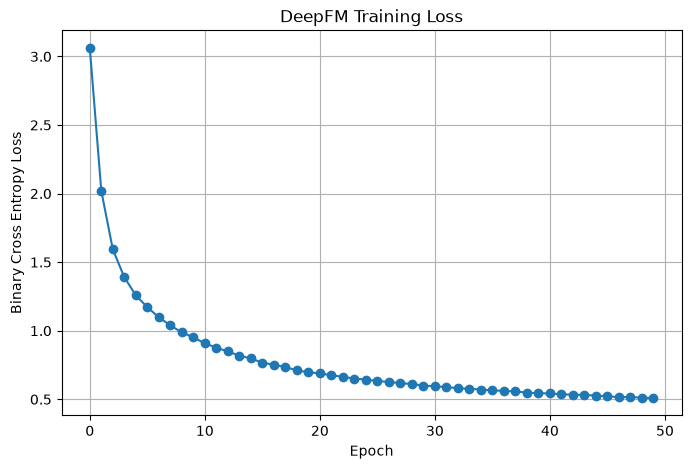

In [36]:
plt.figure(figsize=(8,5))

plt.plot(

    history,

    marker="o"

)

plt.title("DeepFM Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Binary Cross Entropy Loss")

plt.grid(True)

plt.show()

In [37]:
def evaluate_model(

    model,

    test_loader

):

    model.eval()

    predictions = []

    probabilities = []

    labels = []

    with torch.no_grad():

        for (

            user,

            movie,

            gender,

            occupation,

            age,

            genres,

            target

        ) in test_loader:

            logits = model(

                user,

                movie,

                gender,

                occupation,

                age,

                genres

            )

            probs = torch.sigmoid(

                logits

            )

            preds = (

                probs >= 0.5

            ).float()

            probabilities.extend(

                probs.cpu().numpy()

            )

            predictions.extend(

                preds.cpu().numpy()

            )

            labels.extend(

                target.cpu().numpy()

            )

    accuracy = accuracy_score(

        labels,

        predictions

    )

    auc = roc_auc_score(

        labels,

        probabilities

    )

    return (

        accuracy,

        auc,

        np.array(probabilities),

        np.array(predictions),

        np.array(labels)

    )

In [38]:
accuracy, auc, probabilities, predictions, labels = evaluate_model(

    model,

    test_loader

)

print(f"Accuracy : {accuracy:.4f}")

print(f"AUC : {auc:.4f}")

Accuracy : 0.6816
AUC : 0.7386


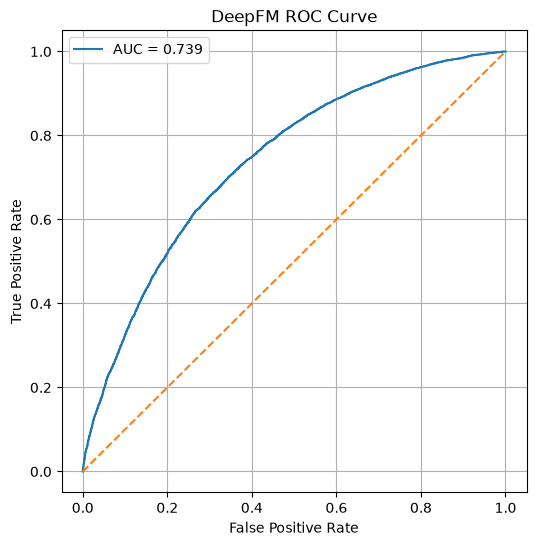

In [39]:
fpr, tpr, _ = roc_curve(

    labels,

    probabilities

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("DeepFM ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [40]:
prediction_df = test_df.copy()

prediction_df["probability"] = probabilities

prediction_df["prediction"] = predictions

prediction_df.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code,title,release_date,...,Romance,Sci-Fi,Thriller,War,Western,label,gender_idx,occupation_idx,probability,prediction
70309,406,152,4,875042569,0.397260,M,engineer,03261,"Fish Called Wanda, A (1988)",01-Jan-1988,...,0,0,0,0,0,1.0,1,4,0.692866,1.0
14503,241,290,3,879740593,0.452055,M,educator,31404,Absolute Power (1997),14-Feb-1997,...,0,0,1,0,0,0.0,1,3,0.638236,1.0
22229,329,237,5,876546323,0.479452,F,educator,33884,Raising Arizona (1987),01-Jan-1987,...,0,0,0,0,0,1.0,0,3,0.916393,1.0
34450,403,753,3,883790218,0.397260,F,programmer,55108,Red Corner (1997),01-Jan-1997,...,0,0,1,0,0,0.0,0,14,0.454618,0.0
28502,325,43,1,879875852,0.561644,M,administrator,15235,Dolores Claiborne (1994),01-Jan-1994,...,0,0,1,0,0,0.0,1,0,0.277443,0.0


In [41]:
def precision_at_k(

    prediction_df,

    k=10

):

    precisions = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        precisions.append(

            top_k["label"].mean()

        )

    return np.mean(

        precisions

    )

In [42]:
def recall_at_k(

    prediction_df,

    k=10

):

    recalls = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        relevant = group["label"].sum()

        if relevant == 0:

            continue

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits = top_k["label"].sum()

        recalls.append(

            hits / relevant

        )

    return np.mean(

        recalls

    )

In [43]:
def hit_rate_at_k(

    prediction_df,

    k=10

):

    hits = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits.append(

            top_k["label"].sum() > 0

        )

    return np.mean(

        hits

    )

In [44]:
precision = precision_at_k(

    prediction_df,

    k=10

)

recall = recall_at_k(

    prediction_df,

    k=10

)

hitrate = hit_rate_at_k(

    prediction_df,

    k=10

)

metrics = pd.DataFrame(

    {

        "Metric":[

            "Accuracy",

            "AUC",

            "Precision@10",

            "Recall@10",

            "HitRate@10"

        ],

        "Value":[

            accuracy,

            auc,

            precision,

            recall,

            hitrate

        ]

    }

)

metrics

,Metric,Value
0,Accuracy,0.681600
1,AUC,0.738619
2,Precision@10,0.650041
3,Recall@10,0.716934
4,HitRate@10,0.976670


In [45]:
prediction_df[[

    "user_id",

    "movie_id",

    "label",

    "probability",

    "prediction"

]].head(20)

,user_id,movie_id,label,probability,prediction
70309,406,152,1.0,0.692866,1.0
14503,241,290,0.0,0.638236,1.0
22229,329,237,1.0,0.916393,1.0
34450,403,753,0.0,0.454618,0.0
28502,325,43,0.0,0.277443,0.0
78501,758,983,0.0,0.431793,0.0
62828,842,541,0.0,0.000069,0.0
85723,549,14,1.0,0.921296,1.0
99463,775,216,1.0,0.233142,0.0
95612,641,451,0.0,0.143369,0.0


In [46]:
comparison = pd.DataFrame(

    {

        "Model":[

            "Ranking MLP",

            "Wide & Deep",

            "DeepFM"

        ],

        "Accuracy":[

            0.8400,

            0.8334,

            accuracy

        ],

        "AUC":[

            0.7862,

            0.7763,

            auc

        ],

        "Precision@10":[

            0.9102,

            0.8831,

            precision

        ],

        "Recall@10":[

            0.5092,

            0.6886,

            recall

        ],

        "HitRate@10":[

            0.9978,

            0.9957,

            hitrate

        ]

    }

)

comparison

,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
2,DeepFM,0.6816,0.738619,0.650041,0.716934,0.97667


In [47]:
print("Best Accuracy")

display(

    comparison.sort_values(

        "Accuracy",

        ascending=False

    )

)

print("Best AUC")

display(

    comparison.sort_values(

        "AUC",

        ascending=False

    )

)

print("Best Precision@10")

display(

    comparison.sort_values(

        "Precision@10",

        ascending=False

    )

)

print("Best Recall@10")

display(

    comparison.sort_values(

        "Recall@10",

        ascending=False

    )

)

Best Accuracy


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
2,DeepFM,0.6816,0.738619,0.650041,0.716934,0.97667


Best AUC


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
2,DeepFM,0.6816,0.738619,0.650041,0.716934,0.97667


Best Precision@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
2,DeepFM,0.6816,0.738619,0.650041,0.716934,0.97667


Best Recall@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
2,DeepFM,0.6816,0.738619,0.650041,0.716934,0.97667
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.99570
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.99780


# Conclusion

DeepFM combines the strengths of Factorization Machines and Deep Neural Networks through a shared embedding layer.

Observations from this notebook:

- The FM component automatically learns low-order feature interactions.
- The Deep component captures complex nonlinear interactions.
- Unlike Wide & Deep, no manual feature engineering is required.
- Shared embeddings make the model parameter-efficient and easier to train.

DeepFM is widely used for click-through rate prediction and recommendation systems because it learns both memorization and generalization in an end-to-end manner.